# Predicting T-shirt size using the ANSUR II dataset
We will here try to predict a persons t-shirt size given the weight and height of the person. We will use the ANSUR II dataset which contains a lot of information about the physical attributes of a large number of people.
 
We will first try to map the persons in the dataset to a t-shirt size. It is hard to find a concise size chart for t-shirt so we will create our own, initial chart, based on these assumptions:
 
We will only look at two measurements, Shoulder Width and Chest Circumference.
 
Our first problem is that Shoulder Width is not one of the measurements taken in the dataset. But we have Biacromial Breadth which is the distance between the two acromion processes. We will assume that this is the same as Shoulder Width.
 
We will then have these initial rules:
 
| Size | Percentile |
|------|------------|
| XS   | 0-5        |
| S    | 5-25       |
| M    | 25-50      |
| L    | 50-75      |
| XL   | 75-90      |
| XXL  | 90-97      |
| XXXL | 97-100     |

# Lab 3

Earlier in the project, we mentioned that there might be conflicts when comparing sizes based on different measurements (e.g., chest circumference and shoulder breadth). For instance, a person might have size S for chest but size M for shoulders. Your task is to get a clearer picture of how many individuals have matching sizes for both measurements and how many have different sizes (i.e., they fall into different sizes for shoulder breadth and chest circumference).
 
Use the size chart: Use a size chart that specifies the limits for shoulder breadth and chest circumference for each size.
 
Create a function: Write a function that iterates through each person's measurements and compares them with the size chart.
 
Count matches and conflicts: The function should count the number of individuals who have exactly one matching size and the number of individuals who have multiple possible sizes (conflicts).
 
Test your function with both female and male datasets, and use appropriate size charts for each gender.

## Inspect the data

In [159]:
import pandas as pd
import numpy as np


In [160]:
female = pd.read_csv('./data/female.csv')
male = pd.read_csv('./data/male.csv')

In [161]:
print(f'For women we have (rows, columns) {female.shape}')
print(f'For men we have (rows, columns) {male.shape}')

For women we have (rows, columns) (1986, 108)
For men we have (rows, columns) (4082, 108)


## Checking the percentiles

In [162]:
def compute_percentile_ranges(column):
    # Define percentile ranges
    ranges = [(0,5), (5,25), (25,50), (50,75), (75,90), (90,97), (97,100)]
    
    percentiles = {(low, high): (column.quantile(low/100), column.quantile(high/100)) for low, high in ranges}
    
    counts = {}
    
    # range and values make up each items
    for r, (low, high) in percentiles.items():
        counts[r] = int(((column >= low) & (column < high)).sum())
        
    return counts
        
        
print(compute_percentile_ranges(female['chestcircumference']))
print(compute_percentile_ranges(female['biacromialbreadth']))

{(0, 5): 100, (5, 25): 396, (25, 50): 492, (50, 75): 499, (75, 90): 299, (90, 97): 140, (97, 100): 59}
{(0, 5): 93, (5, 25): 377, (25, 50): 477, (50, 75): 541, (75, 90): 297, (90, 97): 139, (97, 100): 61}


In [163]:

print(compute_percentile_ranges(male['chestcircumference']))
print(compute_percentile_ranges(male['biacromialbreadth']))

{(0, 5): 199, (5, 25): 810, (25, 50): 1025, (50, 75): 1012, (75, 90): 616, (90, 97): 295, (97, 100): 124}
{(0, 5): 191, (5, 25): 787, (25, 50): 989, (50, 75): 1079, (75, 90): 610, (90, 97): 303, (97, 100): 122}


## Generate the t-shirt size chart

In [164]:
def compute_size_percentile_measurements(data, chest_column, shoulder_column):
    sizes = ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL']
    ranges = [0, 5, 25, 50, 75, 90, 97]  # lowest percentile value for each
    
    # Compute the values for each percentile for chest and shoulder
    chest_percentiles = {p: data[chest_column].quantile(p/100) for p in ranges}
    shoulder_percentiles = {p: data[shoulder_column].quantile(p/100) for p in ranges}
    
    # Map the t-shirt sizes to the corresponding chest and shoulder measurements
    size_mappings = {}
    for i, size in enumerate(sizes):
        size_mappings[size] = {
            'Chest': int(chest_percentiles[ranges[i]]),
            'Shoulder': int(shoulder_percentiles[ranges[i]])
        }
    return size_mappings
    
print(compute_size_percentile_measurements(female, 'chestcircumference', 'biacromialbreadth'))
print(compute_size_percentile_measurements(male, 'chestcircumference', 'biacromialbreadth'))
    

{'XS': {'Chest': 695, 'Shoulder': 283}, 'S': {'Chest': 824, 'Shoulder': 335}, 'M': {'Chest': 889, 'Shoulder': 353}, 'L': {'Chest': 940, 'Shoulder': 365}, 'XL': {'Chest': 999, 'Shoulder': 378}, '2XL': {'Chest': 1057, 'Shoulder': 389}, '3XL': {'Chest': 1117, 'Shoulder': 400}}
{'XS': {'Chest': 774, 'Shoulder': 337}, 'S': {'Chest': 922, 'Shoulder': 384}, 'M': {'Chest': 996, 'Shoulder': 403}, 'L': {'Chest': 1056, 'Shoulder': 415}, 'XL': {'Chest': 1117, 'Shoulder': 428}, '2XL': {'Chest': 1172, 'Shoulder': 441}, '3XL': {'Chest': 1233, 'Shoulder': 452}}


In [165]:
female_sizes = {
    'XS': {'Chest': 695, 'Shoulder': 283}, 
    'S': {'Chest': 824, 'Shoulder': 335}, 
    'M': {'Chest': 889, 'Shoulder': 353}, 
    'L': {'Chest': 940, 'Shoulder': 365}, 
    'XL': {'Chest': 999, 'Shoulder': 378}, 
    '2XL': {'Chest': 1057, 'Shoulder': 389}, 
    '3XL': {'Chest': 1117, 'Shoulder': 400}
}
male_sizes = {
    'XS': {'Chest': 774, 'Shoulder': 337}, 
    'S': {'Chest': 922, 'Shoulder': 384}, 
    'M': {'Chest': 996, 'Shoulder': 403}, 
    'L': {'Chest': 1056, 'Shoulder': 415}, 
    'XL': {'Chest': 1117, 'Shoulder': 428}, 
    '2XL': {'Chest': 1172, 'Shoulder': 441}, 
    '3XL': {'Chest': 1233, 'Shoulder': 452}
}

# Lab 3 - Aladdins version

Earlier in the project, we mentioned that there might be conflicts when comparing sizes based on different measurements (e.g., chest circumference and shoulder breadth). For instance, a person might have size S for chest but size M for shoulders. Your task is to get a clearer picture of how many individuals have matching sizes for both measurements and how many have different sizes (i.e., they fall into different sizes for shoulder breadth and chest circumference).
 
Use the size chart: Use a size chart that specifies the limits for shoulder breadth and chest circumference for each size.
 
Create a function: Write a function that iterates through each person's measurements and compares them with the size chart.
 
Count matches and conflicts: The function should count the number of individuals who have exactly one matching size and the number of individuals who have multiple possible sizes (conflicts).
 
Test your function with both female and male datasets, and use appropriate size charts for each gender.

In [166]:
def get_size(data, size_chart):
    matches = {size: 0 for size in size_chart.keys()}
    ties = 0
    
    for _, row in data.iterrows():
        possible_sizes = []
        
        for size, measurements in size_chart.items():
            if (row['biacromialbreadth'] <= measurements['Shoulder'] and row['chestcircumference'] <= measurements['Chest']):
                possible_sizes.append(size)
        if len(possible_sizes) == 1:
            matches[possible_sizes[0]] += 1
        elif len(possible_sizes) > 1:
            ties += 1
    return matches, ties
            

female_matches, female_ties = get_size(female, female_sizes)

male_matches, male_ties = get_size(male, male_sizes)

print('Female matches:', female_matches)
print('Female ties:', female_ties)
print('Male matches:', male_matches)
print('Male ties:', male_ties)

Female matches: {'XS': 0, 'S': 0, 'M': 0, 'L': 0, 'XL': 0, '2XL': 0, '3XL': 236}
Female ties: 1642
Male matches: {'XS': 0, 'S': 0, 'M': 0, 'L': 0, 'XL': 0, '2XL': 0, '3XL': 434}
Male ties: 3437


# Lesson 4

Overlapping measurements

In [167]:
def create_overlapping_size_chart(original_chart):
    overlapping_chart = {}
    
    sizes = list(original_chart.keys())
    
    for i, size in enumerate(sizes):
        overlapping_chart[size] = {}
        if i == 0:
            overlapping_chart[size]['Chest'] = [original_chart[size]['Chest'], original_chart[sizes[i+1]]['Chest']+5]
            overlapping_chart[size]['Shoulder'] = [original_chart[size]['Shoulder'], original_chart[sizes[i+1]]['Shoulder']+5]
        elif i == len(sizes)-1:
            overlapping_chart[size]['Chest'] = [original_chart[size]['Chest']-5, original_chart[size]['Chest']+1000]
            overlapping_chart[size]['Shoulder'] = [original_chart[size]['Shoulder']-5, original_chart[size]['Shoulder']+1000]
        else:
            overlapping_chart[size]['Chest'] = [original_chart[size]['Chest']-5, original_chart[sizes[i+1]]['Chest']+5]
            overlapping_chart[size]['Shoulder'] = [original_chart[size]['Shoulder']-5, original_chart[sizes[i+1]]['Shoulder']+5]
            
    return overlapping_chart

new_female_sizes = create_overlapping_size_chart(female_sizes)
new_male_sizes = create_overlapping_size_chart(male_sizes)

print('new_female_sizes = {')
for k, v in new_female_sizes.items():
        print(f"'{k}': {v},")
print('}')
print('new_male_sizes = {')
for k, v in new_male_sizes.items():
        print(f"'{k}': {v},")
print('}')
    

new_female_sizes = {
'XS': {'Chest': [695, 829], 'Shoulder': [283, 340]},
'S': {'Chest': [819, 894], 'Shoulder': [330, 358]},
'M': {'Chest': [884, 945], 'Shoulder': [348, 370]},
'L': {'Chest': [935, 1004], 'Shoulder': [360, 383]},
'XL': {'Chest': [994, 1062], 'Shoulder': [373, 394]},
'2XL': {'Chest': [1052, 1122], 'Shoulder': [384, 405]},
'3XL': {'Chest': [1112, 2117], 'Shoulder': [395, 1400]},
}
new_male_sizes = {
'XS': {'Chest': [774, 927], 'Shoulder': [337, 389]},
'S': {'Chest': [917, 1001], 'Shoulder': [379, 408]},
'M': {'Chest': [991, 1061], 'Shoulder': [398, 420]},
'L': {'Chest': [1051, 1122], 'Shoulder': [410, 433]},
'XL': {'Chest': [1112, 1177], 'Shoulder': [423, 446]},
'2XL': {'Chest': [1167, 1238], 'Shoulder': [436, 457]},
'3XL': {'Chest': [1228, 2233], 'Shoulder': [447, 1452]},
}


Put the sizes into dictionaries

In [168]:
new_female_sizes = {
'XS': {'Chest': [695, 829], 'Shoulder': [283, 340]},
'S': {'Chest': [819, 894], 'Shoulder': [330, 358]},
'M': {'Chest': [884, 945], 'Shoulder': [348, 370]},
'L': {'Chest': [935, 1004], 'Shoulder': [360, 383]},
'XL': {'Chest': [994, 1062], 'Shoulder': [373, 394]},
'2XL': {'Chest': [1052, 1122], 'Shoulder': [384, 405]},
'3XL': {'Chest': [1112, 2117], 'Shoulder': [395, 1400]},
}
new_male_sizes = {
'XS': {'Chest': [774, 927], 'Shoulder': [337, 389]},
'S': {'Chest': [917, 1001], 'Shoulder': [379, 408]},
'M': {'Chest': [991, 1061], 'Shoulder': [398, 420]},
'L': {'Chest': [1051, 1122], 'Shoulder': [410, 433]},
'XL': {'Chest': [1112, 1177], 'Shoulder': [423, 446]},
'2XL': {'Chest': [1167, 1238], 'Shoulder': [436, 457]},
'3XL': {'Chest': [1228, 2233], 'Shoulder': [447, 1452]},
}

# Lab 4

Last time, we created a function get_size to get a clearer view of how many matches and ties we had. Now, I want you to do the same thing for the new size charts we created, but this time taking into consideration that we have two measurements instead of one. The goal remains the same: find out how many matches and how many ties we have.
 
Task
Analyze the data: Use the new size charts to determine the number of matches and ties based on two measurements.
Count matches and ties: Write a function that iterates through each person's measurements, compares them with the new size charts, and counts the number of matches and ties.
Bonus
Modify the function to handle ties. If there is a tie and the sizes are adjacent, choose the larger size to increase the number of matches.
 

In [169]:
def get_size(data, size_chart):
    sizes = ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL']
    matches = {size: 0 for size in size_chart.keys()}
    ties = []
    
    for _, row in data.iterrows():
        chest_sizes = []
        shoulder_sizes = []
        
        for size, measurements in size_chart.items():
            if (measurements['Chest'][0] <= row['chestcircumference'] <= measurements['Chest'][1]):
                chest_sizes.append(size)
            if (measurements['Shoulder'][0] <= row['biacromialbreadth'] <= measurements['Shoulder'][1]):
                shoulder_sizes.append(size)
        possible_sizes = list(set(chest_sizes) & set(shoulder_sizes))
                
        if len(possible_sizes) == 1:
            matches[possible_sizes[0]] += 1
        elif len(possible_sizes) > 1:
            size_indices = [sizes.index(size) for size in possible_sizes]
            largest_size = sizes[max(size_indices)]
            matches[largest_size] += 1
        else:
            assigned = False
            for chest_size in chest_sizes:
                for shoulder_size in shoulder_sizes:
                    chest_idx = sizes.index(chest_size)
                    shoulder_idx = sizes.index(shoulder_size)
                    
                    if abs(chest_idx - shoulder_idx) == 1:
                        larger_size = sizes[max(chest_idx, shoulder_idx)]
                        matches[larger_size] += 1
                        assigned = True
                        break
                if assigned:
                    break
            if not assigned:
                ties.append({
                    'chest_sizes': chest_sizes,
                    'shoulder_sizes': shoulder_sizes,
                    'all_sizes': list(set(chest_sizes + shoulder_sizes))
                })
    
    return matches, ties
            

female_matches, female_ties = get_size(female, new_female_sizes)
male_matches, male_ties = get_size(male, new_male_sizes)


print('Female matches:', female_matches)
print(f'Female ties: {len(female_ties)} ({round(len(female_ties)/len(female)*100)}%)')
print(f'Female percentage matches + ties: {(sum(female_matches.values()) + len(female_ties)) / len(female)*100}% ({(sum(female_matches.values()) + len(female_ties))}/{len(female)})')
print('Male matches:', male_matches)
print(f'Male ties: {len(male_ties)} ({round(len(male_ties)/len(male)*100)}%)')
print(f'Male percentage matches + ties: {(sum(male_matches.values()) + len(male_ties)) / len(male)*100}% ({(sum(male_matches.values()) + len(male_ties))}/{len(male)})')
    

Female matches: {'XS': 23, 'S': 231, 'M': 417, 'L': 485, 'XL': 251, '2XL': 88, '3XL': 28}
Female ties: 463 (23%)
Female percentage matches + ties: 100.0% (1986/1986)
Male matches: {'XS': 63, 'S': 541, 'M': 920, 'L': 991, 'XL': 615, '2XL': 208, '3XL': 104}
Male ties: 640 (16%)
Male percentage matches + ties: 100.0% (4082/4082)


list the sizes for chest and shoulders for the individuals that is in the tie category

In [178]:
print('Female ties:')
for tie in female_ties:
    print(tie)
    

Female ties:
{'chest_sizes': ['S'], 'shoulder_sizes': ['L'], 'all_sizes': ['S', 'L']}
{'chest_sizes': ['S'], 'shoulder_sizes': ['2XL', '3XL'], 'all_sizes': ['3XL', 'S', '2XL']}
{'chest_sizes': ['XL'], 'shoulder_sizes': ['S', 'M'], 'all_sizes': ['S', 'XL', 'M']}
{'chest_sizes': ['XL'], 'shoulder_sizes': ['XS'], 'all_sizes': ['XL', 'XS']}
{'chest_sizes': ['M', 'L'], 'shoulder_sizes': ['3XL'], 'all_sizes': ['3XL', 'L', 'M']}
{'chest_sizes': ['S'], 'shoulder_sizes': ['L'], 'all_sizes': ['S', 'L']}
{'chest_sizes': ['2XL'], 'shoulder_sizes': ['S'], 'all_sizes': ['S', '2XL']}
{'chest_sizes': ['L'], 'shoulder_sizes': ['XS'], 'all_sizes': ['L', 'XS']}
{'chest_sizes': ['2XL', '3XL'], 'shoulder_sizes': ['M', 'L'], 'all_sizes': ['3XL', '2XL', 'L', 'M']}
{'chest_sizes': ['3XL'], 'shoulder_sizes': ['S', 'M'], 'all_sizes': ['3XL', 'S', 'M']}
{'chest_sizes': ['L'], 'shoulder_sizes': ['S'], 'all_sizes': ['S', 'L']}
{'chest_sizes': ['2XL'], 'shoulder_sizes': ['M', 'L'], 'all_sizes': ['2XL', 'L', 'M']}
{

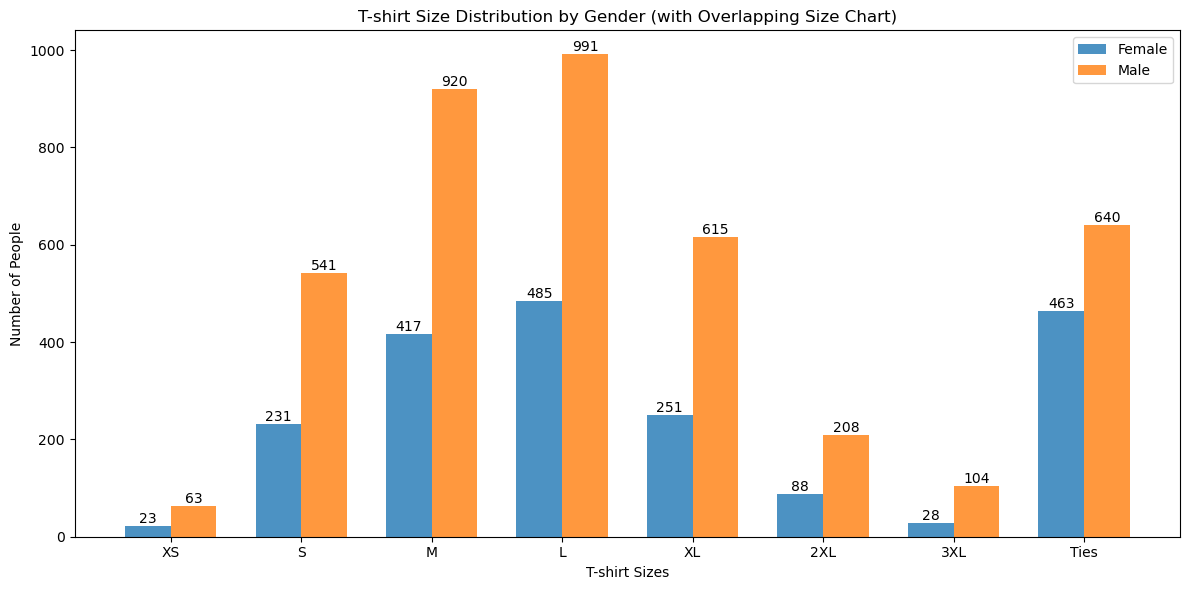

In [173]:
import matplotlib.pyplot as plt
import numpy as np

def plot_size_distribution(female_matches, male_matches, female_ties, male_ties):
    sizes = ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL']
    
    female_counts = [female_matches[size] for size in sizes] + [len(female_ties)]
    male_counts = [male_matches[size] for size in sizes] + [len(male_ties)]
    
    x = np.arange(len(sizes) + 1)
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    bars1 = ax.bar(x - width/2, female_counts, width, label='Female', alpha=0.8)
    bars2 = ax.bar(x + width/2, male_counts, width, label='Male', alpha=0.8)
    
    ax.set_xlabel('T-shirt Sizes')
    ax.set_ylabel('Number of People')
    ax.set_title('T-shirt Size Distribution by Gender (with Overlapping Size Chart)')
    ax.set_xticks(x)
    ax.set_xticklabels(sizes + ['Ties'])
    ax.legend()
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

plot_size_distribution(female_matches, male_matches, female_ties, male_ties)

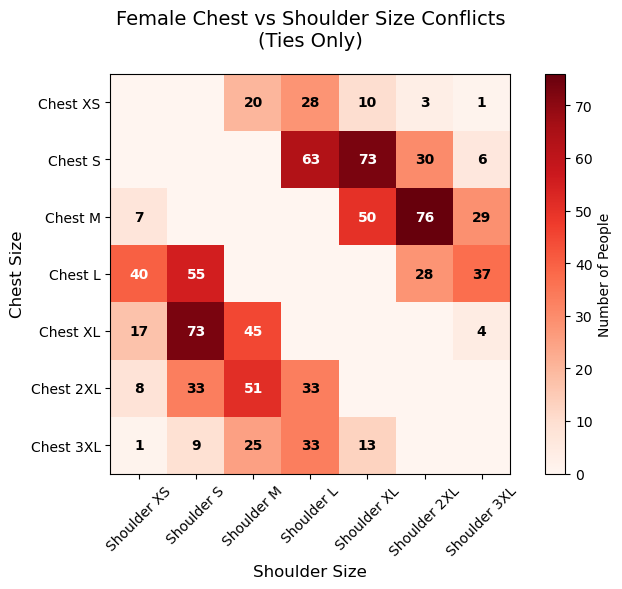

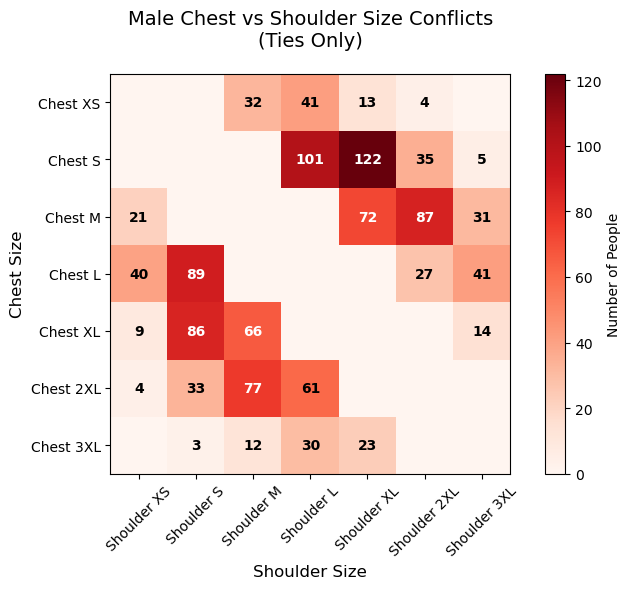

In [179]:
def create_chest_shoulder_conflict_heatmap(ties_data, gender_name):
    sizes = ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL']
    
    # Create matrix showing chest vs shoulder size conflicts
    conflict_matrix = np.zeros((len(sizes), len(sizes)))
    
    for tie in ties_data:
        for chest_size in tie['chest_sizes']:
            for shoulder_size in tie['shoulder_sizes']:
                chest_idx = sizes.index(chest_size)
                shoulder_idx = sizes.index(shoulder_size)
                conflict_matrix[chest_idx][shoulder_idx] += 1
    
    plt.figure(figsize=(8, 6))
    
    # Create heatmap
    im = plt.imshow(conflict_matrix, cmap='Reds', interpolation='nearest')
    
    # Add colorbar
    plt.colorbar(im, label='Number of People')
    
    # Set ticks and labels
    plt.xticks(range(len(sizes)), [f'Shoulder {size}' for size in sizes], rotation=45)
    plt.yticks(range(len(sizes)), [f'Chest {size}' for size in sizes])
    
    # Add text annotations
    for i in range(len(sizes)):
        for j in range(len(sizes)):
            if conflict_matrix[i, j] > 0:
                plt.text(j, i, f'{int(conflict_matrix[i, j])}', 
                        ha='center', va='center', 
                        color='white' if conflict_matrix[i, j] > np.max(conflict_matrix)/2 else 'black',
                        fontweight='bold')
    
    plt.title(f'{gender_name} Chest vs Shoulder Size Conflicts\n(Ties Only)', fontsize=14, pad=20)
    plt.xlabel('Shoulder Size', fontsize=12)
    plt.ylabel('Chest Size', fontsize=12)
    plt.tight_layout()
    plt.show()

# Create the heatmaps
create_chest_shoulder_conflict_heatmap(female_ties, 'Female')
create_chest_shoulder_conflict_heatmap(male_ties, 'Male')

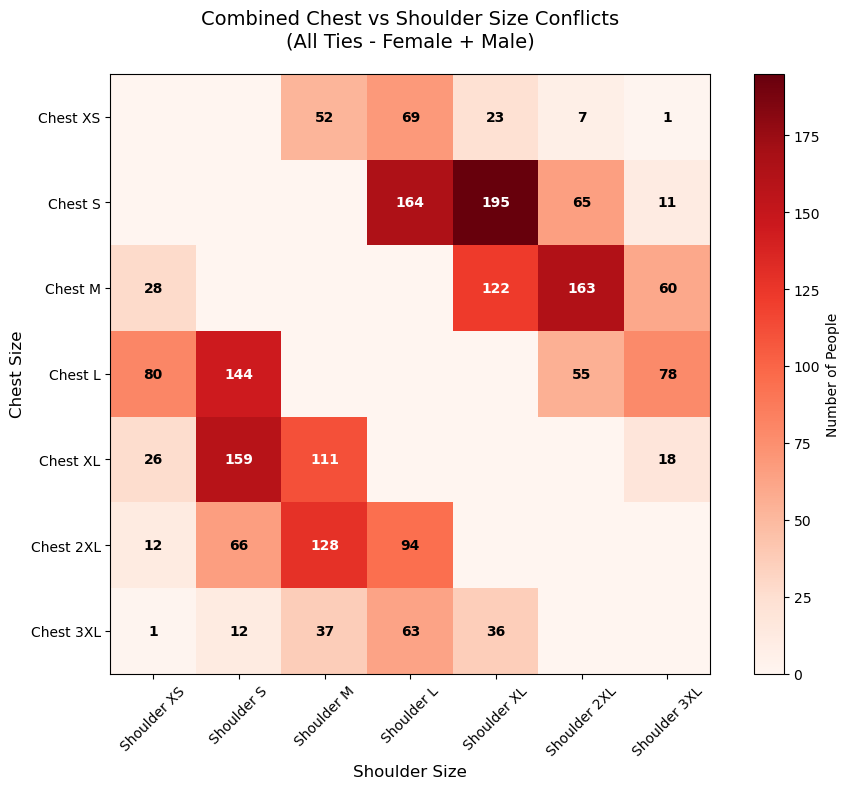

Total conflicts: 1103 people (463 female + 640 male)


In [177]:
def create_combined_chest_shoulder_conflict_heatmap(female_ties, male_ties):
    sizes = ['XS', 'S', 'M', 'L', 'XL', '2XL', '3XL']
    
    # Create combined matrix
    combined_matrix = np.zeros((len(sizes), len(sizes)))
    
    # Add female conflicts
    for tie in female_ties:
        for chest_size in tie['chest_sizes']:
            for shoulder_size in tie['shoulder_sizes']:
                chest_idx = sizes.index(chest_size)
                shoulder_idx = sizes.index(shoulder_size)
                combined_matrix[chest_idx][shoulder_idx] += 1
    
    # Add male conflicts
    for tie in male_ties:
        for chest_size in tie['chest_sizes']:
            for shoulder_size in tie['shoulder_sizes']:
                chest_idx = sizes.index(chest_size)
                shoulder_idx = sizes.index(shoulder_size)
                combined_matrix[chest_idx][shoulder_idx] += 1
    
    plt.figure(figsize=(10, 8))
    
    # Create heatmap
    im = plt.imshow(combined_matrix, cmap='Reds', interpolation='nearest')
    
    # Add colorbar
    plt.colorbar(im, label='Number of People')
    
    # Set ticks and labels
    plt.xticks(range(len(sizes)), [f'Shoulder {size}' for size in sizes], rotation=45)
    plt.yticks(range(len(sizes)), [f'Chest {size}' for size in sizes])
    
    # Add text annotations
    for i in range(len(sizes)):
        for j in range(len(sizes)):
            if combined_matrix[i, j] > 0:
                plt.text(j, i, f'{int(combined_matrix[i, j])}', 
                        ha='center', va='center', 
                        color='white' if combined_matrix[i, j] > np.max(combined_matrix)/2 else 'black',
                        fontweight='bold')
    
    plt.title('Combined Chest vs Shoulder Size Conflicts\n(All Ties - Female + Male)', fontsize=14, pad=20)
    plt.xlabel('Shoulder Size', fontsize=12)
    plt.ylabel('Chest Size', fontsize=12)
    plt.tight_layout()
    plt.show()
    
    # Print summary
    total_conflicts = len(female_ties) + len(male_ties)
    print(f"Total conflicts: {total_conflicts} people ({len(female_ties)} female + {len(male_ties)} male)")

# Create the combined heatmap
create_combined_chest_shoulder_conflict_heatmap(female_ties, male_ties)